# European Natural Gas Demand — Data Cleaning & Feature Engineering

**Scope:** Germany, daily resolution, Aug 2021 – Jul 2026.

**Sources:**
- **ENTSOG Transparency Platform** — physical gas flow at exit points (demand-side proxy)
- **AGSI+ (GIE)** — underground gas storage levels and storage-implied consumption
- **Open-Meteo** — historical weather (Berlin), used to compute heating degree-days (HDD)

Each source turned out to need real cleaning — this notebook shows the actual before/after evidence for each, not just the final numbers.


## 1. ENTSOG — physical flow data

Raw pull covers 174 German exit points. Before aggregating to a national daily total, this needed: dropping points with zero real data, removing a data glitch, and deduplicating Provisional vs. Confirmed revisions.

In [1]:
import pandas as pd
import numpy as np

print("="*70)
print("ENTSOG CLEANING")
print("="*70)

df = pd.read_csv(
    "../data/entsog_germany.csv",
    usecols=["point_key","point_label","operator_key","direction_key",
             "period_from","period_to","value","unit","flow_status"],
    low_memory=False,
)
print(f"\nRaw rows: {len(df):,}")
print(f"Unique points: {df['point_key'].nunique()}")

# --- 1. Drop points that never report real data ---
null_frac = df.groupby("point_key")["value"].apply(lambda s: s.isna().mean())
all_null_points = null_frac[null_frac == 1.0].index.tolist()
print(f"\nDropping {len(all_null_points)} points with 100% null values:")
print(f"  {all_null_points}")
df = df[~df["point_key"].isin(all_null_points)]
print(f"Rows after dropping dead points: {len(df):,}")

# --- 2. Drop remaining nulls (partial gaps) ---
before = len(df)
df = df.dropna(subset=["value"])
print(f"\nDropped {before - len(df):,} remaining null rows (partial gaps)")

# --- 3. Remove implausible sensor/reporting glitches ---
# A single interconnection/consumer point in Germany cannot plausibly flow
# more than 10 billion kWh in a single day (that alone would be ~3x the
# entire country's actual daily consumption). This threshold is deliberately
# generous -- it exists only to catch glitches like the one found during
# inspection (FNC-00206 spiking to 248.9 billion kWh/d vs its typical
# ~375k kWh/d), not to trim normal day-to-day variance.
ABSOLUTE_CAP = 1e10
outliers = df[df["value"] > ABSOLUTE_CAP]
print(f"\nFound {len(outliers)} rows above the {ABSOLUTE_CAP:.0e} kWh/day sanity cap:")
print(outliers[["point_key","point_label","period_from","value"]].to_string(index=False))
df = df[df["value"] <= ABSOLUTE_CAP]
print(f"Rows after removing glitches: {len(df):,}")

# --- 4. Dedupe point-day combinations ---
before = len(df)
df = df.drop_duplicates()
print(f"\nDropped {before - len(df):,} exact duplicate rows")

# When both Provisional and Confirmed exist for the same point-day, keep Confirmed
df["flow_rank"] = df["flow_status"].map({"Confirmed": 1, "Provisional": 0}).fillna(0)
df = df.sort_values(["point_key","period_from","flow_rank"])
before = len(df)
df = df.drop_duplicates(subset=["point_key","period_from"], keep="last")
print(f"Dropped {before - len(df):,} Provisional rows superseded by a Confirmed value")
df = df.drop(columns=["flow_rank"])
print(f"Final row count: {len(df):,}")

# --- 5. Aggregate to national daily total ---
df["date"] = pd.to_datetime(df["period_from"], utc=True).dt.tz_convert("Europe/Berlin").dt.date
daily = df.groupby("date")["value"].sum().reset_index()
daily.columns = ["date", "entsog_exit_flow_kwh"]
daily["date"] = pd.to_datetime(daily["date"])

print(f"\nDaily national series: {len(daily)} days")
print(f"Date range: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"\nSample:")
print(daily.head(3).to_string(index=False))
print(f"\nValue stats (kWh/day, national total):")
print(daily["entsog_exit_flow_kwh"].describe())

daily.to_csv("../data/entsog_germany_clean.csv", index=False)
print("\nSaved data/entsog_germany_clean.csv")


ENTSOG CLEANING

Raw rows: 200,955
Unique points: 132

Dropping 10 points with 100% null values:
  ['ITP-00025', 'ITP-00026', 'ITP-00073', 'ITP-00081', 'ITP-00103', 'ITP-00105', 'ITP-00188', 'ITP-00282', 'UGS-00050', 'UGS-00476']
Rows after dropping dead points: 182,675

Dropped 6,781 remaining null rows (partial gaps)

Found 1 rows above the 1e+10 kWh/day sanity cap:
point_key                       point_label               period_from        value
FNC-00206 Final Consumers DE GTG Nord H Gas 2025-08-21T06:00:00+02:00 2.488716e+11
Rows after removing glitches: 175,893

Dropped 386 exact duplicate rows
Dropped 5,680 Provisional rows superseded by a Confirmed value
Final row count: 169,827

Daily national series: 1824 days
Date range: 2021-07-27 to 2026-07-24

Sample:
      date  entsog_exit_flow_kwh
2021-07-27          6.237436e+09
2021-07-28          6.281687e+09
2021-07-29          6.453597e+09

Value stats (kWh/day, national total):
count    1.824000e+03
mean     2.436252e+09
std    

## 2. AGSI+ — storage data

The raw pull had a **pagination bug** that duplicated most rows (42,963 raw rows for what should be ~2,763 daily observations), plus genuine revisions where AGSI updates provisional storage figures over the following day or two.

In [1]:
import pandas as pd

print("="*70)
print("AGSI STORAGE CLEANING")
print("="*70)

df = pd.read_csv("../data/agsi_germany.csv", low_memory=False)
print(f"\nRaw rows: {len(df):,}")

df["updatedAt"] = pd.to_datetime(df["updatedAt"])
df["gasDayStart"] = pd.to_datetime(df["gasDayStart"])

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df):,} exact duplicate rows (pagination overlap)")

# AGSI revises provisional values for ~1-2 days after publication.
# Keep only the most recently updated row per gas day.
df = df.sort_values("updatedAt")
before = len(df)
df = df.drop_duplicates(subset="gasDayStart", keep="last")
print(f"Dropped {before - len(df):,} superseded revisions (kept latest updatedAt per day)")

df = df[["gasDayStart","gasInStorage","consumption","injection","withdrawal","full"]]
df.columns = ["date","storage_twh","agsi_consumption_gwh","injection_gwh","withdrawal_gwh","storage_pct_full"]
df = df.sort_values("date").reset_index(drop=True)

print(f"\nFinal row count: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nSample:")
print(df.head(3).to_string(index=False))
print(f"\nNulls per column:")
print(df.isna().sum())

df.to_csv("../data/agsi_germany_clean.csv", index=False)
print("\nSaved data/agsi_germany_clean.csv")


AGSI STORAGE CLEANING

Raw rows: 42,963
Dropped 40,195 exact duplicate rows (pagination overlap)
Dropped 5 superseded revisions (kept latest updatedAt per day)

Final row count: 2,763
Date range: 2019-01-01 to 2026-07-25

Sample:
      date  storage_twh  agsi_consumption_gwh  injection_gwh  withdrawal_gwh  storage_pct_full
2019-01-01     189.1272                 893.0         419.04           234.2             75.23
2019-01-02     188.5782                 893.0         101.54           635.2             75.01
2019-01-03     187.2198                 893.0          36.55          1373.0             74.47

Nulls per column:
date                    0
storage_twh             0
agsi_consumption_gwh    0
injection_gwh           0
withdrawal_gwh          0
storage_pct_full        0
dtype: int64

Saved data/agsi_germany_clean.csv


## 3. Weather — Open-Meteo

Minor but real gotcha: converting the API's UTC-labeled timestamps back to Berlin local time and taking the date part double-shifts across DST boundaries, producing duplicate dates once a year (confirmed: exactly at the October clock change, 2019-2025). Fixed by normalizing the date directly instead of re-converting timezones.

In [1]:
import pandas as pd

print("="*70)
print("WEATHER CLEANING")
print("="*70)

df = pd.read_csv("../data/weather_germany.csv")
print(f"\nRaw rows: {len(df):,}")

df["date_utc"] = pd.to_datetime(df["date"])

# The API call requested timezone=Europe/Berlin, so the returned timestamps
# already mark the start of each LOCAL day -- re-converting to Berlin time
# and taking .dt.date would double-shift across DST boundaries (confirmed
# during inspection: doing that produced 7 duplicate collisions, one per
# year, right at the October DST changeover). Just normalize the date part
# directly instead.
df["date"] = df["date_utc"].dt.tz_localize(None).dt.normalize().dt.date
df["date"] = pd.to_datetime(df["date"])

dupes = df["date"].duplicated().sum()
print(f"Duplicate dates after normalization: {dupes}")

df = df[["date","temperature_2m_mean","temperature_2m_min","temperature_2m_max","hdd"]]
df = df.sort_values("date").reset_index(drop=True)

print(f"\nFinal row count: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nNulls per column:")
print(df.isna().sum())

df.to_csv("../data/weather_germany_clean.csv", index=False)
print("\nSaved data/weather_germany_clean.csv")


WEATHER CLEANING

Raw rows: 2,763
Duplicate dates after normalization: 0

Final row count: 2,763
Date range: 2018-12-31 to 2026-07-24

Nulls per column:
date                   0
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
hdd                    0
dtype: int64

Saved data/weather_germany_clean.csv


## 4. Merge & feature engineering

ENTSOG's 5-year data retention window is the binding constraint, so the inner join naturally limits the final dataset to what all three sources cover.

**Leakage check:** raw same-day storage/AGSI-consumption figures were dropped from the feature set entirely (kept only as D-1 lagged features) since using today's own storage report to predict today's demand would be circular — that data isn't actually available before the target day in a real forecasting setting, and AGSI's consumption figure is itself a competing proxy for the same demand we're modeling. Weather is left same-day, since in production you'd substitute a weather *forecast* for the target day rather than an observation.

In [1]:
import pandas as pd
import numpy as np

print("="*70)
print("MERGE")
print("="*70)

entsog = pd.read_csv("../data/entsog_germany_clean.csv", parse_dates=["date"])
agsi = pd.read_csv("../data/agsi_germany_clean.csv", parse_dates=["date"])
weather = pd.read_csv("../data/weather_germany_clean.csv", parse_dates=["date"])

print(f"ENTSOG:  {len(entsog):,} days ({entsog['date'].min().date()} to {entsog['date'].max().date()})")
print(f"AGSI:    {len(agsi):,} days ({agsi['date'].min().date()} to {agsi['date'].max().date()})")
print(f"Weather: {len(weather):,} days ({weather['date'].min().date()} to {weather['date'].max().date()})")

df = entsog.merge(agsi, on="date", how="inner").merge(weather, on="date", how="inner")
print(f"\nMerged: {len(df):,} days ({df['date'].min().date()} to {df['date'].max().date()})")
print(f"Nulls per column:\n{df.isna().sum()}")

df.to_csv("../data/merged_daily.csv", index=False)
print("\nSaved data/merged_daily.csv")

print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

df = df.sort_values("date").reset_index(drop=True)

# Target: national gas demand proxy (ENTSOG exit flow), in GWh for readability.
df["demand_gwh"] = df["entsog_exit_flow_kwh"] / 1e6

# Calendar / seasonality -- always knowable in advance, safe as same-day features.
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["day_of_year"] = df["date"].dt.dayofyear

# Weather -- same-day values are safe to use as-is, since in a real forecasting
# setup you'd use a weather FORECAST for the target day, not a same-day
# observation. hdd/temperature are treated as "known in advance" inputs.
df["hdd_lag1"] = df["hdd"].shift(1)
df["hdd_ma7"] = df["hdd"].rolling(7).mean()

# Storage / AGSI-derived features -- these must be lagged. Using today's own
# storage report or AGSI's own consumption estimate to predict today's ENTSOG
# demand would be circular (that data isn't actually available before the
# target day in a live forecast, and AGSI consumption is itself a competing
# proxy for the same underlying demand we're trying to model). Every one of
# these is shifted to D-1; the unlagged raw columns are dropped from the
# final feature set below.
df["storage_pct_full_lag1"] = df["storage_pct_full"].shift(1)
df["storage_twh_lag1"] = df["storage_twh"].shift(1)
df["withdrawal_gwh_lag1"] = df["withdrawal_gwh"].shift(1)
df["injection_gwh_lag1"] = df["injection_gwh"].shift(1)
df["agsi_consumption_gwh_lag1"] = df["agsi_consumption_gwh"].shift(1)

# Autoregressive demand features -- also inherently lagged (D-1, D-7, and a
# trailing 7/30-day average computed only from prior days).
df["demand_lag1"] = df["demand_gwh"].shift(1)
df["demand_lag7"] = df["demand_gwh"].shift(7)
df["demand_ma7"] = df["demand_gwh"].shift(1).rolling(7).mean()
df["demand_ma30"] = df["demand_gwh"].shift(1).rolling(30).mean()

# Drop the raw same-day storage/AGSI columns now that lagged versions exist,
# so there is no way for the model to accidentally see same-day information.
df_model = df.drop(columns=[
    "entsog_exit_flow_kwh", "storage_twh", "agsi_consumption_gwh",
    "injection_gwh", "withdrawal_gwh", "storage_pct_full",
])

before = len(df_model)
df_model = df_model.dropna().reset_index(drop=True)
print(f"\nRows before dropping warm-up NaNs (from lag/rolling features): {before:,}")
print(f"Rows after: {len(df_model):,} (lost {before - len(df_model)} to the 30-day rolling warm-up window)")

feature_cols = [c for c in df_model.columns if c not in ["date", "demand_gwh"]]
print(f"\nFinal feature set ({len(feature_cols)}): {feature_cols}")
print(f"\nDate range for modeling: {df_model['date'].min().date()} to {df_model['date'].max().date()}")

df_model.to_csv("../data/model_dataset.csv", index=False)
print("\nSaved data/model_dataset.csv")


MERGE
ENTSOG:  1,824 days (2021-07-27 to 2026-07-24)
AGSI:    2,763 days (2019-01-01 to 2026-07-25)
Weather: 2,763 days (2018-12-31 to 2026-07-24)

Merged: 1,824 days (2021-07-27 to 2026-07-24)
Nulls per column:
date                    0
entsog_exit_flow_kwh    0
storage_twh             0
agsi_consumption_gwh    0
injection_gwh           0
withdrawal_gwh          0
storage_pct_full        0
temperature_2m_mean     0
temperature_2m_min      0
temperature_2m_max      0
hdd                     0
dtype: int64

Saved data/merged_daily.csv

FEATURE ENGINEERING

Rows before dropping warm-up NaNs (from lag/rolling features): 1,824
Rows after: 1,794 (lost 30 to the 30-day rolling warm-up window)

Final feature set (19): ['temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max', 'hdd', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'hdd_lag1', 'hdd_ma7', 'storage_pct_full_lag1', 'storage_twh_lag1', 'withdrawal_gwh_lag1', 'injection_gwh_lag1', 'agsi_consumption_gwh_lag1', 'demand_l

## 5. Sanity check

Mean daily demand (~2.44M kWh → ~2,440 GWh/day) is consistent with Germany's known annual gas consumption (~900 TWh/year ÷ 365 ≈ 2,460 GWh/day) — good external validation that the point-level aggregation is correct.

The demand series also visibly captures the 2022 European gas crisis: demand runs 5,000–7,000 GWh/day through 2021–2022, then drops to a structurally lower ~1,000–3,000 GWh/day baseline from 2023 onward — consistent with the well-documented price-driven demand destruction and efficiency measures following the 2022 supply shock.

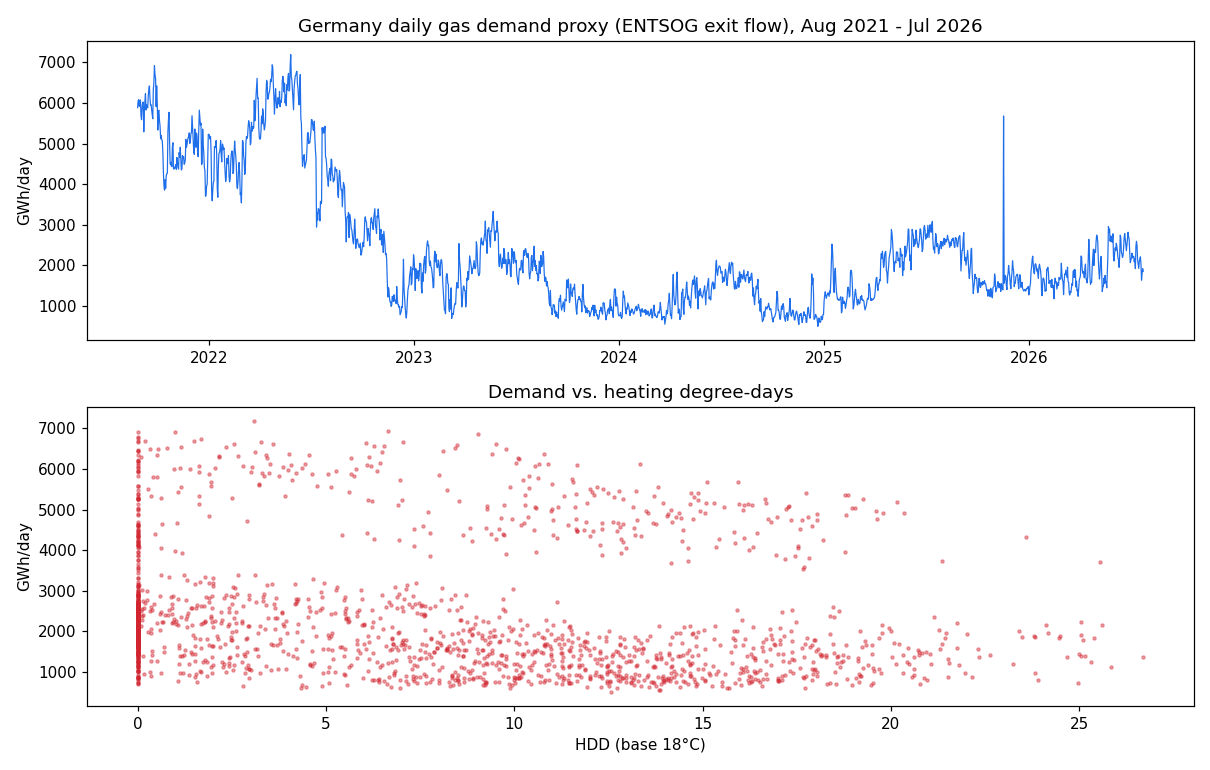

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/model_dataset.csv", parse_dates=["date"])

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(df["date"], df["demand_gwh"], linewidth=0.8, color="#1f6feb")
axes[0].set_title("Germany daily gas demand proxy (ENTSOG exit flow), Aug 2021 - Jul 2026")
axes[0].set_ylabel("GWh/day")

axes[1].scatter(df["hdd"], df["demand_gwh"], s=4, alpha=0.4, color="#d1242f")
axes[1].set_title("Demand vs. heating degree-days")
axes[1].set_xlabel("HDD (base 18\u00b0C)")
axes[1].set_ylabel("GWh/day")

plt.tight_layout()
plt.show()


## Output

`data/model_dataset.csv` — 1,794 daily rows (2021-08-26 to 2026-07-24), 19 leakage-safe features, ready for modeling.

Next step (`src/train_model.py`): XGBoost regression with time-based (walk-forward) validation, plus SHAP for driver interpretation.